In [1]:
%matplotlib widget

In [2]:
# %load_ext autoreload

In [3]:
import numpy as np
import panel as pn
from IPython.display import display

In [4]:
pn.extension('tabulator')

In [5]:
from libertem.api import Context

from microscope_calibration.common.model import Model4DSTEM, DescanError, PixelYX
from microscope_calibration.ui import CoordinateCorrectionLayout
from microscope_calibration.util.diffraction import get_twothetas

In [6]:
from hyperspy import api as hs

In [7]:
somefile = hs.load('/storage/er-c-data/adhoc/livecalibration/2026-08-27-CEA-JEOL/raw/MicroscopeCal/mag150kX_cl20cm_ca40um_z30um_roi.dm4', lazy=True)

In [8]:
somefile.metadata

├── Acquisition_instrument
│   └── TEM
│       ├── Stage
│       │   ├── tilt_alpha = -0.385158747434616
│       │   ├── tilt_beta = -0.00148847815580666
│       │   ├── x = 0.0812766799926758
│       │   ├── y = 0.4054736328125
│       │   └── z = 0.0323194580078125
│       ├── acquisition_mode = STEM
│       ├── beam_current = 0.0
│       ├── beam_energy = 200.0
│       ├── camera_length = 200.0
│       ├── dwell_time = 5e-07
│       └── magnification = 150000.0
├── General
│   ├── FileIO
│   │   └── 0
│   │       ├── hyperspy_version = 2.4.0
│   │       ├── io_plugin = rsciio.digitalmicrograph
│   │       ├── operation = load
│   │       └── timestamp = 2026-09-02T11:01:56.065138+02:00
│   ├── date = 2026-08-27
│   ├── original_filename = mag150kX_cl20cm_ca40um_z30um_roi.dm4
│   ├── time = 14:47:10
│   └── title = mag150kX_cl20cm_ca40um_z30um_roi
├── Sample
│   └── description = xgrating-focal-series
└── Signal
    ├── Noise_properties
    │   └── Variance_linear_model
    │       ├── gain_factor = 0.008984725922346115
    │       └── gain_offset = 0.0
    ├── quantity = Electrons (Counts)
    └── signal_type =

In [9]:
import ncempy

In [10]:
somefile2 = ncempy.io.dm.fileDM('/storage/er-c-data/adhoc/livecalibration/2026-08-27-CEA-JEOL/raw/MicroscopeCal/mag150kX_cl20cm_ca40um_z30um_roi.dm4')

In [11]:
somefile2.allTags

{'.ApplicationBounds': array([   0.,    0., 1742., 2718.]),
 '.BackgroundColor': array([-2571., -2571., -1286.]),
 '.DocumentObjectList.1.AnnotationType': np.int32(20),
 '.DocumentObjectList.1.BackgroundColor': array([-1., -1., -1.]),
 '.DocumentObjectList.1.BackgroundMode': np.int16(2),
 '.DocumentObjectList.1.FillMode': np.int16(1),
 '.DocumentObjectList.1.ForegroundColor': array([-1.,  0.,  0.]),
 '.DocumentObjectList.1.HasBackground': np.uint8(0),
 '.DocumentObjectList.1.ImageDisplayInfo.BrightColor': array([-1., -1., -1.]),
 '.DocumentObjectList.1.ImageDisplayInfo.Brightness': np.float32(0.5),
 '.DocumentObjectList.1.ImageDisplayInfo.CaptionOn': np.uint8(0),
 '.DocumentObjectList.1.ImageDisplayInfo.CaptionSize': np.uint16(14),
 '.DocumentObjectList.1.ImageDisplayInfo.CLUT.arraySize': np.uint64(1536),
 '.DocumentObjectList.1.ImageDisplayInfo.CLUT.arrayOffset': 1210,
 '.DocumentObjectList.1.ImageDisplayInfo.CLUT.arrayType': np.float64(2.0),
 '.DocumentObjectList.1.ImageDisplayInfo.C

In [12]:
somefile2.allTags['.ImageList.2.ImageTags.Microscope Info.Voltage']

np.float64(200000.0)

In [13]:
acceleration_voltage_V = somefile2.allTags['.ImageList.2.ImageTags.Microscope Info.Voltage']

In [14]:
# structure_filename = 'BiFeO3EntryWithCollCode29921.cif'
structure_filename = 'AuEntryWithCollCode163723.cif'

In [15]:
twothetas = get_twothetas(structure_filename, acceleration_voltage_V, reciprocal_radius=3)
twothetas

array([0.     , 0.00308, 0.00533, 0.00616, 0.00689, 0.00871, 0.01022,
       0.01067, 0.01232, 0.01343, 0.01377, 0.01509, 0.01601, 0.01742,
       0.01822, 0.01848, 0.01948, 0.0202 , 0.02043, 0.02134, 0.022  ,
       0.02221, 0.02305, 0.02366, 0.02464, 0.02521, 0.0254 , 0.02614,
       0.02668, 0.02685, 0.02755, 0.02806, 0.02823, 0.0289 , 0.02939,
       0.03018, 0.03065, 0.03081, 0.03142, 0.03187, 0.03201, 0.03304,
       0.03318, 0.03375, 0.03417, 0.03485, 0.03526, 0.03539, 0.03593,
       0.03632, 0.03645, 0.03697, 0.03735, 0.03748])

In [35]:
# calib_filename = '/storage/er-c-data/adhoc/libertem/libertem-test-data/default.blo'
# calib_filename = 'with_descan.npy'
calib_filename = '/storage/er-c-data/adhoc/livecalibration/2026-08-27-CEA-JEOL/raw/MicroscopeCal/mag150kX_cl40cm_ca40um_z150um_roi.dm4'

In [36]:
grid = 1e-3 / 2160
grid * 1e9

462.962962962963

In [37]:
grid * 1e9 * 2

925.925925925926

In [38]:
ncempy.io.dm.fileDM(calib_filename).allTags

{'.ApplicationBounds': array([   0.,    0., 1742., 2718.]),
 '.BackgroundColor': array([-2571., -2571., -1286.]),
 '.DocumentObjectList.1.AnnotationGroupList.1.AnnotationType': np.int32(23),
 '.DocumentObjectList.1.AnnotationGroupList.1.BackgroundColor': array([-1., -1., -1.]),
 '.DocumentObjectList.1.AnnotationGroupList.1.BackgroundMode': np.int16(2),
 '.DocumentObjectList.1.AnnotationGroupList.1.BorderThickness': np.float32(1.0),
 '.DocumentObjectList.1.AnnotationGroupList.1.Color': array([-1.,  0.,  0.]),
 '.DocumentObjectList.1.AnnotationGroupList.1.DrawFill': np.uint8(1),
 '.DocumentObjectList.1.AnnotationGroupList.1.FillColor': array([-1.,  0.,  0.]),
 '.DocumentObjectList.1.AnnotationGroupList.1.FillMode': np.int16(2),
 '.DocumentObjectList.1.AnnotationGroupList.1.FillTransparency': np.float32(0.8),
 '.DocumentObjectList.1.AnnotationGroupList.1.ForegroundColor': array([-1.,  0.,  0.]),
 '.DocumentObjectList.1.AnnotationGroupList.1.HasBackground': np.uint8(0),
 '.DocumentObjectLi

In [39]:
ctx = Context.make_with(cpus=8)
# ctx = Context.make_with('inline')

/home/weber/miniforge3/envs/calib314/lib/python3.14/site-packages/distributed/node.py:195: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 41283 instead
  warnings.warn(


In [40]:
ds = ctx.load('auto', calib_filename)

In [41]:
start_model = None

Column
    [0] Markdown(str, max_width=500)
    [1] Row
        [0] FloatInput(label='Scan rotation / degrees', name='Scan rotation / degrees')
        [1] FloatInput(label='Detector pixel p..., name='Detector pixel p..., value=50.0)
        [2] FloatInput(label='Camera length / m', name='Camera length / m', step=0.01, value=1.0)
        [3] FloatInput(label='Convergence s..., name='Convergence s..., step=0.01, value=1.0)
    [2] Row
        [0] Column(margin=(3, 3), max_height=500, max_width=500)
            [0] Row(height=40, margin=(0, 0))
                [0] FloatPanel(config={'headerControls': {'maxim...}, contained=False, name='Image Controls', objects=[Row
    [0] Select(label=...], position='center', status='closed')
                [1] Row(height=40, margin=(0, 0))
                [2] Toggle(height=2, label='Image Controls', margin=(5, 5, 5, 5), name='Image Controls', sizing_mode='fixed', tags=['cd01d132-1682-494f-8345-...], visible=False, width=2)
            [1] Bokeh(figure)
        [1] Column(margin=(3, 3), max_height=500, max_width=500)
            [0] Row(height=40, margin=(0, 0))
                [0] FloatPanel(config={'headerControls': {'maxim...}, contained=False, name='Image Controls', objects=[Row
    [0] Select(label=...], position='center', status='closed')
                [1] Row(height=40, margin=(0, 0))
                [2] Toggle(height=2, label='Image Controls', margin=(5, 5, 5, 5), name='Image Controls', sizing_mode='fixed', tags=['0301dc03-f115-4d0d-9d70-...], visible=False, width=2)
            [1] Bokeh(figure)
    [3] Column
        [0] Markdown(str)
        [1] Tabulator(buttons={'select': '<i class="fa f...}, selectable=False, value=Empty DataFrame
Columns: [...)
        [2] Row
            [0] Button(label='Record', name='Record')
            [1] Button(label='Apply correction f..., name='Apply correction f...)
            [2] Button(label='Clear', name='Clear')
            [3] Button(label='Refine correction w..., name='Refine correction w...)
    [4] Markdown(str, max_width=500)
    [5] Row
        [0] Column(margin=(3, 3), max_height=500, max_width=500)
            [0] Row(height=40, margin=(0, 0))
                [0] FloatPanel(config={'headerControls': {'maxim...}, contained=False, name='Image Controls', objects=[Row
    [0] Select(label=...], position='center', status='closed')
                [1] Row(height=40, margin=(0, 0))
                [2] Toggle(height=2, label='Image Controls', margin=(5, 5, 5, 5), name='Image Controls', sizing_mode='fixed', tags=['5717971e-fd44-42c3-9f16-...], visible=False, width=2)
            [1] Bokeh(figure)
        [1] Column(margin=(3, 3), max_height=500, max_width=500)
            [0] Row(height=40, margin=(0, 0))
                [0] FloatPanel(config={'headerControls': {'maxim...}, contained=False, name='Image Controls', objects=[Row
    [0] Select(label=...], position='center', status='closed')
                [1] Row(height=40, margin=(0, 0))
                [2] Toggle(height=2, label='Image Controls', margin=(5, 5, 5, 5), name='Image Controls', sizing_mode='fixed', tags=['f2de234c-7c4a-49e2-8d13-...], visible=False, width=2)
            [1] Bokeh(figure)
        [2] Column(margin=(3, 3), max_height=500, max_width=500)
            [0] Row(height=40, margin=(0, 0))
                [0] FloatPanel(config={'headerControls': {'maxim...}, contained=False, name='Image Controls', objects=[Row
    [0] Select(label=...], position='center', status='closed')
                [1] Row(height=40, margin=(0, 0))
                [2] Toggle(height=2, label='Image Controls', margin=(5, 5, 5, 5), name='Image Controls', sizing_mode='fixed', tags=['4f7782b1-0312-49a7-bccf-...], visible=False, width=2)
            [1] Bokeh(figure)
    [6] Row
        [0] FloatInput(label='Scale bar / nm', name='Scale bar / nm', step=0.01, value=np.float64(89600.0))
    [7] Row
        [0] Column(margin=(3, 3), max_height=500, max_width=500)
            [0] Row(height=40, margin=(0, 0))
    
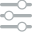
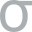
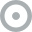
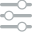
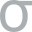
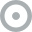
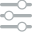
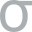
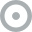
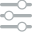
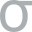
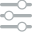
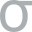
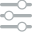
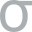
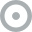
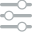
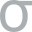
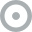
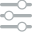
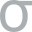
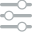
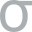

In [52]:
gui = CoordinateCorrectionLayout(
    dataset=ds,
    nav_mode='point',
    sig_mode='log',
    ctx=ctx,
    start_model=start_model,
#    twothetas=twothetas,
    # twothetas=np.array([0.,1.]),
    # twothetas=None,
    twothetas=twothetas,
)
display(gui.layout.servable())

In [43]:
curr_model = gui.model

In [44]:
curr_model

Model4DSTEM(overfocus=0.0, scan_pixel_pitch=1e-06, scan_center=PixelYX(y=64.0, x=64.0), scan_rotation=0.0, camera_length=0.3, detector_pixel_pitch=1.5e-05, detector_center=PixelYX(y=256.0, x=256.0), semiconv=0.0001, flip_factor=1.0, descan_error=DescanError(pxo_pxi=0.0, pxo_pyi=0.0, pyo_pxi=0.0, pyo_pyi=0.0, sxo_pxi=-4.6342018332129715, sxo_pyi=4.668539935122746, syo_pxi=-4.306400113172294, syo_pyi=-5.282113062140293, offpxi=0.0, offpyi=0.0, offsxi=-0.0006665509688555086, offsyi=0.0003198730112167648), detector_rotation=0.0)

In [46]:
calib_filename_2 = '/storage/er-c-data/adhoc/livecalibration/2026-08-27-CEA-JEOL/raw/MicroscopeCal/mag150kX_cl40cm_ca150um_z150um_roi.dm4'

In [47]:
next_model = curr_model.derive()

In [48]:
next_ds = ctx.load('auto', path=calib_filename_2)

Column
    [0] Markdown(str, max_width=500)
    [1] Row
        [0] FloatInput(label='Scan rotation / degrees', name='Scan rotation / degrees')
        [1] FloatInput(label='Detector pixel p..., name='Detector pixel p..., value=15.0)
        [2] FloatInput(label='Camera length / m', name='Camera length / m', step=0.01, value=0.3)
        [3] FloatInput(label='Convergence s..., name='Convergence s..., step=0.01, value=0.1)
    [2] Row
        [0] Column(margin=(3, 3), max_height=500, max_width=500)
            [0] Row(height=40, margin=(0, 0))
                [0] FloatPanel(config={'headerControls': {'maxim...}, contained=False, name='Image Controls', objects=[Row
    [0] Select(label=...], position='center', status='closed')
                [1] Row(height=40, margin=(0, 0))
                [2] Toggle(height=2, label='Image Controls', margin=(5, 5, 5, 5), name='Image Controls', sizing_mode='fixed', tags=['c1ccc7be-88e0-416c-90cc-...], visible=False, width=2)
            [1] Bokeh(figure)
        [1] Column(margin=(3, 3), max_height=500, max_width=500)
            [0] Row(height=40, margin=(0, 0))
                [0] FloatPanel(config={'headerControls': {'maxim...}, contained=False, name='Image Controls', objects=[Row
    [0] Select(label=...], position='center', status='closed')
                [1] Row(height=40, margin=(0, 0))
                [2] Toggle(height=2, label='Image Controls', margin=(5, 5, 5, 5), name='Image Controls', sizing_mode='fixed', tags=['c9bad32e-f10f-47fd-883e-...], visible=False, width=2)
            [1] Bokeh(figure)
    [3] Column
        [0] Markdown(str)
        [1] Tabulator(buttons={'select': '<i class="fa f...}, selectable=False, value=Empty DataFrame
Columns: [...)
        [2] Row
            [0] Button(label='Record', name='Record')
            [1] Button(label='Apply correction f..., name='Apply correction f...)
            [2] Button(label='Clear', name='Clear')
            [3] Button(label='Refine correction w..., name='Refine correction w...)
    [4] Markdown(str, max_width=500)
    [5] Row
        [0] Column(margin=(3, 3), max_height=500, max_width=500)
            [0] Row(height=40, margin=(0, 0))
                [0] FloatPanel(config={'headerControls': {'maxim...}, contained=False, name='Image Controls', objects=[Row
    [0] Select(label=...], position='center', status='closed')
                [1] Row(height=40, margin=(0, 0))
                [2] Toggle(height=2, label='Image Controls', margin=(5, 5, 5, 5), name='Image Controls', sizing_mode='fixed', tags=['a4a14770-8d52-4382-9e62-...], visible=False, width=2)
            [1] Bokeh(figure)
        [1] Column(margin=(3, 3), max_height=500, max_width=500)
            [0] Row(height=40, margin=(0, 0))
                [0] FloatPanel(config={'headerControls': {'maxim...}, contained=False, name='Image Controls', objects=[Row
    [0] Select(label=...], position='center', status='closed')
                [1] Row(height=40, margin=(0, 0))
                [2] Toggle(height=2, label='Image Controls', margin=(5, 5, 5, 5), name='Image Controls', sizing_mode='fixed', tags=['80852c93-1d75-4d51-93ed-...], visible=False, width=2)
            [1] Bokeh(figure)
        [2] Column(margin=(3, 3), max_height=500, max_width=500)
            [0] Row(height=40, margin=(0, 0))
                [0] FloatPanel(config={'headerControls': {'maxim...}, contained=False, name='Image Controls', objects=[Row
    [0] Select(label=...], position='center', status='closed')
                [1] Row(height=40, margin=(0, 0))
                [2] Toggle(height=2, label='Image Controls', margin=(5, 5, 5, 5), name='Image Controls', sizing_mode='fixed', tags=['25ec7eff-507f-4fd1-857f-...], visible=False, width=2)
            [1] Bokeh(figure)
    [6] Row
        [0] FloatInput(label='Scale bar / nm', name='Scale bar / nm', step=0.01, value=np.float64(89600.0))
    [7] Row
        [0] Column(margin=(3, 3), max_height=500, max_width=500)
            [0] Row(height=40, margin=(0, 0))
    
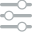
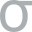
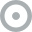
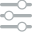
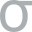
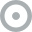
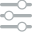
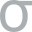
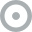
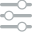
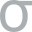
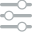
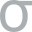
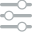
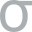
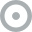
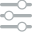
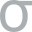
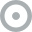
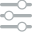
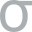
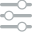
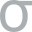

In [51]:
# %autoreload
next_gui = CoordinateCorrectionLayout(
    dataset=next_ds,
    nav_mode='point',
    sig_mode='log',
    ctx=ctx,
    start_model=next_model,
#    twothetas=twothetas,
    # twothetas=np.array([0.,1.]),
    # twothetas=None,
    #twothetas=twothetas,
)
display(next_gui.layout.servable())

In [ ]:
overfocus_tmp_params = next_gui.params

In [ ]:
overfocus_tmp_params

In [ ]:
overfocus_filename = '/storage/er-c-data/adhoc/livecalibration/2025-11-21-hitachidata/unzipped/Overfocus_1/data.npy'

In [ ]:
overfocus_meta_filename = '/storage/er-c-data/adhoc/livecalibration/2025-11-21-hitachidata/unzipped/Overfocus_1/meta_data.npy'

In [ ]:
overfocus_meta = np.load(overfocus_meta_filename, allow_pickle=True)
overfocus_meta[0]

In [ ]:
overfocus_params = overfocus_tmp_params.derive(
    scan_pixel_pitch=curr_params.scan_pixel_pitch * meta[0]['scan_driver.magnification'] / overfocus_meta[0]['scan_driver.magnification']
)

In [ ]:
overfocus_ds = ctx.load('auto', path=overfocus_filename)

In [ ]:
%autoreload
overfocus_gui = CoordinateCorrectionLayout(
    dataset=overfocus_ds,
    nav_mode='point',
    sig_mode='lin',
    ctx=ctx,
    # start_params=overfocus_params,
    start_params=my_params,
#    twothetas=twothetas,
    # twothetas=np.array([0.,1.]),
    # twothetas=None,
    #twothetas=twothetas,
)
display(overfocus_gui.layout.servable())

In [ ]:
overfocus_gui.params

In [ ]:
my_params = overfocus_gui.params

In [ ]:
from typing import NamedTuple

import jax.numpy as jnp
import optimistix

from microscope_calibration.common.model import trace

In [ ]:
class _CoordPointArgs(NamedTuple):
    params: Parameters4DSTEM
    # [(scan_y, scan_x, detector_y, detector_x) * n]
    points: jnp.array

In [ ]:
def _coords_point_loss(y, args: _CoordPointArgs):
    detector_rotation, overfocus, flip_factor = y[:3]
    tilts = y[3:]

    assert len(tilts) == 2 * len(points)
    
    opt_params = args.params.derive(
        detector_rotation=detector_rotation,
        overfocus=overfocus,
        flip_factor=flip_factor,
    )

    detector_distances = []
    specimen_hits = []
    for i, (scan_y, scan_x, det_y, det_x) in enumerate(args.points):
        dy, dx = tilts[2*i:2*i + 2]
        res = trace(
            opt_params, scan_pos=PixelYX(y=scan_y, x=scan_x), source_dx=dx, source_dy=dy)
        detector_distances.extend((
            det_y - res['detector'].sampling['detector_px'].y,
            det_x - res['detector'].sampling['detector_px'].x,
        ))
        specimen_hits.append((
            res['specimen'].sampling['scan_px'].y,
            res['specimen'].sampling['scan_px'].x
        ))
    specimen_arr = jnp.array(specimen_hits)
    specimen_var = jnp.var(specimen_arr, axis=0)
    aspect = jnp.array((jnp.abs(jnp.abs(flip_factor) - 1) * 100, ))
    return jnp.concatenate((jnp.array(detector_distances), specimen_var, aspect))

In [ ]:
points = gui.coord_fixpoint_table.value.reset_index().to_numpy()

In [ ]:
points

In [ ]:
params = gui.params

In [ ]:
def solve_coords_points(ref_params: Parameters4DSTEM, points: jnp.ndarray):
    args = _CoordPointArgs(
        params=ref_params,
        points=points,
    )

    start = jnp.array([ref_params.detector_rotation, ref_params.overfocus, ref_params.flip_factor] + [0., 0.] * len(points))
    opt_res = optimistix.least_squares(
        fn=_coords_point_loss,
        args=args,
        # FIXME Doesn't reach 1e-12 like the others, for unknown reasons
        solver=optimistix.BFGS(atol=1e-11, rtol=1e-11),
        y0=start,
        # FIXME needs more steps than others, for unknown reasons
        max_steps=10000,
    )
    residual = _coords_point_loss(opt_res.value, args)
    # Write the new tilts and offsets into the previous descan error
    detector_rotation, overfocus, flip_factor = opt_res.value[:3]
    res_params = ref_params.derive(
        detector_rotation=detector_rotation,
        overfocus=overfocus,
        flip_factor=flip_factor,
    ).normalize_types()

    return res_params, residual

In [ ]:
new_param, residuals = solve_coords_points(params, points)

In [ ]:
gui.update_with_force(gui.model_params, gui.params_update(new_param))